In [3]:
import pandas as pd

# Input files
PROBE_ROWS_PATH = "/content/probe_results_rows.csv"
TOPUP_ROWS_PATH = "/content/probe_results_topup_rows.csv"

# Output file
OUT_PATH = "/content/probe_results_combined.csv"

TIME_COL_CANDIDATES = ["start_time_utc", "timestamp", "time", "created_at", "start_time", "ts"]


def pick_existing_col(df, candidates):
    cols = set(df.columns)
    for c in candidates:
        if c in cols:
            return c
    raise ValueError(f"Could not find a time column. Found columns: {sorted(df.columns)}")


def parse_utc(series):
    return pd.to_datetime(series, utc=True, errors="coerce")


probe = pd.read_csv(PROBE_ROWS_PATH)
topup = pd.read_csv(TOPUP_ROWS_PATH)

probe_time_col = pick_existing_col(probe, TIME_COL_CANDIDATES)
topup_time_col = pick_existing_col(topup, TIME_COL_CANDIDATES)

probe[probe_time_col] = parse_utc(probe[probe_time_col])
topup[topup_time_col] = parse_utc(topup[topup_time_col])

probe = probe.loc[probe[probe_time_col].notna()].copy()
topup = topup.loc[topup[topup_time_col].notna()].copy()

if topup_time_col != probe_time_col:
    topup = topup.rename(columns={topup_time_col: probe_time_col})

time_col = probe_time_col

combined = pd.concat([probe, topup], ignore_index=True)
combined = combined.sort_values(time_col, kind="mergesort").reset_index(drop=True)

# Save
combined.to_csv(OUT_PATH, index=False)

print(f"Saved combined file to: {OUT_PATH}")
print(f"Rows in probe file: {len(probe)}")
print(f"Rows in topup file: {len(topup)}")
print(f"Rows in combined file: {len(combined)}")
print(f"Start time: {combined[time_col].min()}")
print(f"End time:   {combined[time_col].max()}")

Saved combined file to: /content/probe_results_combined.csv
Rows in probe file: 6412
Rows in topup file: 1099
Rows in combined file: 7511
Start time: 2026-02-07 02:53:13.958572+00:00
End time:   2026-02-19 04:14:17.608585+00:00


In [4]:

import json
import warnings
from collections import deque

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import roc_auc_score

warnings.filterwarnings("ignore", category=UserWarning)

# ============================================================
# Config
# ============================================================
CSV_PATH = "/content/probe_results_combined.csv"

TIME_COL = "start_time_utc"
CREATED_COL = "created_at"
EVENT_TIME_COL = "event_time"

MAX_HOURS_PER_RUN = 5
TEST_FRACTION = 0.20
RANDOM_STATE = 42

ALPHA_PRIOR = 0.5
BETA_PRIOR = 2.0

POOL_COLS = ["provider", "region", "instance_type"]

TARGET_RATE_COL = "y_block_rate"
TARGET_COUNT_COL = "y_block_count"
TARGET_BIN_COL = "y_block_bin"
TARGET_HORIZON_COL = "y_block_horizon"

CALIB_FRACTION_WITHIN_TRAIN_FULL = 0.15

ECE_BINS = 20
EPS = 1e-15

EWMA_HALF_LIFE_H = 24.0
LAST24_WINDOW_H = 24.0
K_GRID = [0.0, 1.0, 2.0, 5.0, 10.0, 25.0, 50.0]
DELTA_CAP = 2.0

# ============================================================
# Actual fixed model parameters
# ============================================================
FIXED_ALPHA = 0.9838235589992128
FIXED_L2_REGULARIZATION = 0.8378401206547694
FIXED_MAX_DEPTH = 4
FIXED_MAX_LEAF_NODES = 5
FIXED_MIN_SAMPLES_LEAF = 649
FIXED_TEMP = 1.406058625756019

# ============================================================
# Decision setup
# ============================================================
TRAIN_MODEL_ON_LAUNCH_ONLY = True
DECISION_USE_LAUNCH_ONLY = True
PRICE_COL = "spot_price_usd"
REALIZED_POLICY_RISK_COL = TARGET_RATE_COL

USE_TAIL_FAIL_COST = False

FIXED_BASELINE = {
    "east": {"c6i.large": 0.20, "m6a.large": 0.075, "t3a.large": 0.20},
    "west": {"c6i.large": 0.175, "m6a.large": 0.025, "t3a.large": 0.025},
}

RUN_ID_COL = "run_id"

# ============================================================
# Three pools to compare
# ============================================================
TARGET_POOLS = [
    ("us-east-1", "c6i.large"),
    ("us-east-1", "t3a.large"),
    ("us-west-2", "t3a.large"),
]


In [5]:

# ============================================================
# Helpers / metrics
# ============================================================
def safe_parse_dt(s):
    try:
        return pd.to_datetime(s, utc=True)
    except Exception:
        return pd.NaT

def sigmoid(z):
    z = np.asarray(z, dtype=float)
    out = np.empty_like(z, dtype=float)
    m = (z >= 0)
    out[m] = 1.0 / (1.0 + np.exp(-z[m]))
    ez = np.exp(z[~m])
    out[~m] = ez / (1.0 + ez)
    return out

def logit(p, eps=EPS):
    p = np.clip(np.asarray(p, dtype=float), eps, 1.0 - eps)
    return np.log(p / (1.0 - p))

def brier_fractional(y_true, p_pred):
    y = np.asarray(y_true, dtype=float)
    p = np.clip(np.asarray(p_pred, dtype=float), 0.0, 1.0)
    return float(np.mean((p - y) ** 2))

def mae_fractional(y_true, p_pred):
    y = np.asarray(y_true, dtype=float)
    p = np.clip(np.asarray(p_pred, dtype=float), 0.0, 1.0)
    return float(np.mean(np.abs(p - y)))

def log_loss_fractional(y_true, p_pred, eps=EPS):
    y = np.asarray(y_true, dtype=float)
    p = np.clip(np.asarray(p_pred, dtype=float), eps, 1.0 - eps)
    ll = -(y * np.log(p) + (1.0 - y) * np.log(1.0 - p))
    return float(np.mean(ll))

def ece_score(y_true, p_pred, n_bins=20):
    y = np.asarray(y_true, dtype=float)
    p = np.clip(np.asarray(p_pred, dtype=float), 0.0, 1.0)
    edges = np.linspace(0.0, 1.0, int(n_bins) + 1)
    bin_ids = np.minimum(np.digitize(p, edges, right=False) - 1, n_bins - 1)
    bin_ids = np.maximum(bin_ids, 0)
    ece = 0.0
    n_total = len(y)
    for b in range(n_bins):
        m = (bin_ids == b)
        n_b = int(np.sum(m))
        if n_b == 0:
            continue
        pred_b = float(np.mean(p[m]))
        true_b = float(np.mean(y[m]))
        ece += (n_b / max(1, n_total)) * abs(pred_b - true_b)
    return float(ece)

def auc_safe(y_bin, p_pred):
    try:
        return float(roc_auc_score(np.asarray(y_bin, int), np.asarray(p_pred, float)))
    except Exception:
        return float("nan")

def apply_temperature(p, temp):
    z = logit(p, eps=EPS)
    z = z / float(max(1e-9, temp))
    return np.clip(sigmoid(z), EPS, 1.0 - EPS)

def print_metrics_block(title, y_rate, y_bin, p_model, global_q, extra_baselines=None):
    y_rate = np.asarray(y_rate, float)
    y_bin = np.asarray(y_bin, int)
    p_model = np.asarray(p_model, float)
    p0 = np.zeros_like(p_model)
    p_global_overall = np.full_like(p_model, float(np.clip(global_q, EPS, 1.0 - EPS)))
    rows = [("model", p_model), ("global_overall", p_global_overall), ("always_0", p0)]
    if extra_baselines:
        for name, p in extra_baselines.items():
            p = np.asarray(p, float)
            if len(p) == len(p_model):
                rows.append((str(name), np.clip(p, EPS, 1.0 - EPS)))
    print("\n==============================")
    print(title)
    print("==============================")
    for name, p in rows:
        print(
            f"{name:<14} -> "
            f"Brier: {brier_fractional(y_rate, p):.6f} | "
            f"LogLoss: {log_loss_fractional(y_rate, p):.6f} | "
            f"MAE: {mae_fractional(y_rate, p):.6f} | "
            f"ECE: {ece_score(y_rate, p, n_bins=ECE_BINS):.6f} | "
            f"AUC: {auc_safe(y_bin, np.clip(p, 0, 1)):.3f}"
        )

def expected_retry_cost_one_hour(price, fail_prob, horizon, include_tail_fail=False):
    p = np.asarray(price, dtype=float)
    q = np.clip(np.asarray(fail_prob, dtype=float), 0.0, 1.0)
    H = int(max(1, horizon))
    out = np.zeros(np.broadcast(p, q).shape, dtype=float)
    for h in range(1, H + 1):
        out = out + (h * p) * (q ** (h - 1)) * (1.0 - q)
    if include_tail_fail:
        out = out + (H * p) * (q ** H)
    return out

def add_expected_cost_columns(df, horizon):
    out = df.copy()
    prob_cols = ["p_hat", "p_ewma_only", "p_last24", "p_fixed_map", "p_global_avg"]
    for c in prob_cols:
        if c in out.columns:
            out[f"ecost_{c.replace('p_', '')}"] = expected_retry_cost_one_hour(
                price=out[PRICE_COL].values,
                fail_prob=out[c].values,
                horizon=horizon,
                include_tail_fail=USE_TAIL_FAIL_COST,
            )
    out["ecost_realized"] = expected_retry_cost_one_hour(
        price=out[PRICE_COL].values,
        fail_prob=out["realized_policy_risk"].values,
        horizon=horizon,
        include_tail_fail=USE_TAIL_FAIL_COST,
    )
    return out

def spearman_from_rank_lists(rank_a, rank_b):
    a = np.asarray(rank_a, dtype=float)
    b = np.asarray(rank_b, dtype=float)
    n = len(a)
    if n <= 1:
        return np.nan
    d2 = np.sum((a - b) ** 2)
    return float(1.0 - (6.0 * d2) / (n * (n**2 - 1.0)))

def pairwise_accuracy_from_orders(pred_order, true_order):
    items = list(true_order)
    pos_true = {k: i for i, k in enumerate(true_order)}
    pos_pred = {k: i for i, k in enumerate(pred_order)}
    correct = 0
    total = 0
    for i in range(len(items)):
        for j in range(i + 1, len(items)):
            a = items[i]
            b = items[j]
            total += 1
            true_cmp = pos_true[a] < pos_true[b]
            pred_cmp = pos_pred[a] < pos_pred[b]
            if true_cmp == pred_cmp:
                correct += 1
    return float(correct / total) if total > 0 else np.nan

def normalize_region(s):
    s = str(s).strip().lower().replace("_", "-")
    if s == "uswest2":
        return "us-west-2"
    if s == "useast1":
        return "us-east-1"
    if s == "useast2":
        return "us-east-2"
    return s

def pool_label(region, instance_type):
    return f"{normalize_region(region)} | {str(instance_type).strip().lower()}"


In [6]:

# ============================================================
# Baseline helpers / load / slice / split / target / model helpers
# ============================================================
def _norm_region_bucket(region):
    r = str(region).strip().lower()
    if "east" in r:
        return "east"
    if "west" in r:
        return "west"
    return None

def fixed_lookup_prob(region, instance_type, fallback):
    bucket = _norm_region_bucket(region)
    it = str(instance_type).strip().lower()
    if bucket is None:
        return float(np.clip(fallback, EPS, 1.0 - EPS))
    p = FIXED_BASELINE.get(bucket, {}).get(it, None)
    if p is None:
        return float(np.clip(fallback, EPS, 1.0 - EPS))
    return float(np.clip(p, EPS, 1.0 - EPS))

def fixed_lookup_series(df, fallback):
    return np.array([fixed_lookup_prob(r, it, fallback) for r, it in zip(df["region"].values, df["instance_type"].values)], dtype=float)

def build_pool_global_avg_lookup(train_df, fallback):
    grp = train_df.groupby(POOL_COLS, dropna=False)
    lookup = {}
    for key, g in grp:
        numer = float(g[TARGET_COUNT_COL].sum() + ALPHA_PRIOR)
        denom = float(g[TARGET_HORIZON_COL].sum() + ALPHA_PRIOR + BETA_PRIOR)
        p = numer / max(denom, 1e-12)
        lookup[tuple(str(x) for x in key)] = float(np.clip(p, EPS, 1.0 - EPS))
    return lookup, float(np.clip(fallback, EPS, 1.0 - EPS))

def pool_global_avg_series(df, lookup, fallback):
    vals = []
    for _, r in df.iterrows():
        key = tuple(str(r[c]) for c in POOL_COLS)
        vals.append(lookup.get(key, fallback))
    return np.array(vals, dtype=float)

def load_raw(path):
    df = pd.read_csv(path)
    print(f"Loaded rows: {len(df)}")
    df = df.reset_index(drop=True).copy()
    df[RUN_ID_COL] = np.arange(len(df), dtype=np.int64)
    if TIME_COL in df.columns:
        df[TIME_COL] = df[TIME_COL].apply(safe_parse_dt)
    if CREATED_COL in df.columns:
        df[CREATED_COL] = df[CREATED_COL].apply(safe_parse_dt)
    if "features_snapshot" in df.columns:
        def unpack_json(x):
            if isinstance(x, dict):
                return x
            if pd.isna(x):
                return {}
            try:
                return json.loads(x)
            except Exception:
                return {}
        fs = df["features_snapshot"].apply(unpack_json)
        df["fs_launch_local_hour"] = fs.apply(lambda d: d.get("launch_local_hour", np.nan))
        df["fs_launch_utc_hour"] = fs.apply(lambda d: d.get("launch_utc_hour", np.nan))
        df["fs_launch_dow"] = fs.apply(lambda d: d.get("launch_dow", np.nan))
        df["fs_price_zscore_6h"] = fs.apply(lambda d: d.get("price_zscore_6h", np.nan))
    out_norm = df.get("outcome", "").astype(str).str.strip().str.lower()
    df["is_launch_failed_int"] = out_norm.str.contains("launchfailed", na=False).astype(int)
    for c in POOL_COLS:
        if c not in df.columns:
            raise ValueError(f"Missing required column: {c}")
    if PRICE_COL not in df.columns:
        df[PRICE_COL] = np.nan
    df[PRICE_COL] = pd.to_numeric(df[PRICE_COL], errors="coerce")
    df["region_norm"] = df["region"].apply(normalize_region)
    df["instance_type_norm"] = df["instance_type"].astype(str).str.strip().str.lower()
    return df

def make_hour_slices(df):
    need = [TIME_COL, "duration_minutes", "interrupted", RUN_ID_COL]
    for c in need:
        if c not in df.columns:
            df[c] = np.nan
    launched_mask = df["is_launch_failed_int"] == 0
    elig = df[launched_mask & df[TIME_COL].notna()].copy()
    rows = []
    for _, r in elig.iterrows():
        t0 = r[TIME_COL]
        dur = r.get("duration_minutes", np.nan)
        intr = bool(r.get("interrupted", False))
        rid = r.get(RUN_ID_COL)
        if pd.isna(dur):
            continue
        total_minutes = float(dur)
        max_slices = int(np.ceil(min(total_minutes, MAX_HOURS_PER_RUN * 60) / 60.0))
        if max_slices <= 0:
            continue
        for k in range(max_slices):
            slice_start = t0 + pd.Timedelta(hours=k)
            lo = k * 60.0
            hi = (k + 1) * 60.0
            if intr and (lo < total_minutes <= hi):
                y = 1
            elif total_minutes > hi or (not intr and total_minutes >= hi):
                y = 0
            else:
                continue
            row = r.to_dict()
            row[EVENT_TIME_COL] = slice_start
            row["slice_k"] = k
            row["y_1h"] = y
            row[RUN_ID_COL] = rid
            rows.append(row)
    return pd.DataFrame(rows)

def add_time_features(d):
    d = d.copy()
    dt = pd.to_datetime(d[EVENT_TIME_COL], utc=True)
    hour = dt.dt.hour.astype(float)
    dow = dt.dt.weekday.astype(float)
    d["sin_hour"] = np.sin(2 * np.pi * hour / 24.0)
    d["cos_hour"] = np.cos(2 * np.pi * hour / 24.0)
    d["sin_dow"] = np.sin(2 * np.pi * dow / 7.0)
    d["cos_dow"] = np.cos(2 * np.pi * dow / 7.0)
    d["is_weekend"] = (dt.dt.weekday >= 5).astype(int)
    h_int = dt.dt.hour.astype(int).values
    tod = np.zeros(len(d), dtype=int)
    tod[(h_int >= 6) & (h_int < 12)] = 1
    tod[(h_int >= 12) & (h_int < 18)] = 2
    tod[(h_int >= 18) & (h_int < 24)] = 3
    d["tod_bin"] = tod
    return d

def time_split_by_run_with_gap(d_slices, test_fraction=0.2, block_hours=6):
    df = d_slices.sort_values(EVENT_TIME_COL).reset_index(drop=True).copy()
    g = df.groupby(RUN_ID_COL, sort=False)
    run_min = g[EVENT_TIME_COL].min()
    run_max = g[EVENT_TIME_COL].max()
    runs = pd.DataFrame({
        RUN_ID_COL: run_min.index.values,
        "run_min_t": pd.to_datetime(run_min.values, utc=True),
        "run_max_t": pd.to_datetime(run_max.values, utc=True),
    }).sort_values("run_min_t").reset_index(drop=True)
    if len(runs) < 10:
        raise ValueError("Too few runs after slicing to split reliably.")
    split_idx = int((1.0 - float(test_fraction)) * len(runs))
    split_idx = min(max(split_idx, 1), len(runs) - 2)
    split_time = pd.to_datetime(runs.loc[split_idx, "run_min_t"], utc=True)
    gap = pd.Timedelta(hours=float(block_hours))
    train_end_time = split_time - gap
    train_run_ids = runs.loc[runs["run_max_t"] <= train_end_time, RUN_ID_COL].values
    test_run_ids = runs.loc[runs["run_min_t"] > split_time, RUN_ID_COL].values
    train_full = df[df[RUN_ID_COL].isin(train_run_ids)].copy().reset_index(drop=True)
    test = df[df[RUN_ID_COL].isin(test_run_ids)].copy().reset_index(drop=True)
    dropped = len(runs) - (len(train_run_ids) + len(test_run_ids))
    print(f"✅ Run-split sizes: train_full={len(train_full)} test={len(test)} (gap={block_hours}h, dropped_runs={dropped})")
    if len(train_full) == 0 or len(test) == 0:
        raise ValueError("Empty train_full or test after enforcing run-split + gap.")
    return train_full, test

def split_train_full_into_core_gap_calib(train_full_raw, block_hours, calib_frac=0.15):
    df = train_full_raw.sort_values(EVENT_TIME_COL).reset_index(drop=True)
    n = len(df)
    n_cal = int(np.ceil(calib_frac * n))
    n_cal = max(1, min(n_cal, n - 1))
    calib_start_idx = n - n_cal
    calib_start_time = pd.to_datetime(df.loc[calib_start_idx, EVENT_TIME_COL], utc=True)
    gap = pd.Timedelta(hours=float(block_hours))
    core_end_time = calib_start_time - gap
    t = pd.to_datetime(df[EVENT_TIME_COL], utc=True)
    train_core_raw = df[t <= core_end_time].copy().reset_index(drop=True)
    calib_raw = df[t >= calib_start_time].copy().reset_index(drop=True)
    print(f"Train_full split (gap={block_hours}h): train_core={len(train_core_raw)} calib={len(calib_raw)}")
    if len(train_core_raw) == 0 or len(calib_raw) == 0:
        raise ValueError("Empty train_core or calib after enforcing core/calib gap.")
    return train_core_raw, calib_raw

def add_pool_block_rate_target_within_df(d, block_hours):
    d = d.copy().reset_index(drop=True)
    d = d.sort_values(POOL_COLS + [EVENT_TIME_COL]).reset_index(drop=True)
    times = pd.to_datetime(d[EVENT_TIME_COL], utc=True).values
    y1 = d["y_1h"].astype(int).values
    n = len(d)
    y_block_count = np.zeros(n, dtype=float)
    y_block_horizon = np.zeros(n, dtype=float)
    H = pd.Timedelta(hours=block_hours)
    grp = d.groupby(POOL_COLS, sort=False, group_keys=False)
    for _, idx in grp.groups.items():
        idx_arr = np.asarray(idx, dtype=int)
        t_pool = times[idx_arr]
        y_pool = y1[idx_arr]
        L = len(idx_arr)
        cum = np.concatenate([[0], np.cumsum(y_pool)])
        e = 0
        for i in range(L):
            t_end = t_pool[i] + H
            while e < L and t_pool[e] < t_end:
                e += 1
            y_block_horizon[idx_arr[i]] = float(e - i)
            y_block_count[idx_arr[i]] = float(cum[e] - cum[i])
    with np.errstate(divide="ignore", invalid="ignore"):
        y_block_rate = np.where(y_block_horizon > 0, y_block_count / y_block_horizon, 0.0)
    d[TARGET_COUNT_COL] = y_block_count
    d[TARGET_RATE_COL] = y_block_rate
    d[TARGET_BIN_COL] = (y_block_count > 0).astype(int)
    d[TARGET_HORIZON_COL] = y_block_horizon
    return d.sort_values(EVENT_TIME_COL).reset_index(drop=True)

def compute_global_q(train_df):
    return float((train_df[TARGET_COUNT_COL].sum() + ALPHA_PRIOR) / (train_df[TARGET_HORIZON_COL].sum() + ALPHA_PRIOR + BETA_PRIOR))

def ewma_alpha(half_life_h, dt_h):
    lam = np.log(2.0) / float(max(1e-9, half_life_h))
    a = 1.0 - np.exp(-lam * float(max(0.0, dt_h)))
    return float(np.clip(a, 0.0, 1.0))

class OnlineEWMA:
    def __init__(self, half_life_h=24.0):
        self.half_life_h = float(half_life_h)
        self.mu = {}
        self.neff = {}
        self.last_t = {}
    def update_one(self, key, t_now, y):
        t_now = pd.to_datetime(t_now, utc=True)
        y = float(np.clip(y, 0.0, 1.0))
        if key not in self.mu:
            self.mu[key] = y
            self.neff[key] = 1.0
            self.last_t[key] = t_now
            return
        dt_h = float((t_now - self.last_t[key]) / np.timedelta64(1, "h"))
        dt_h = max(0.0, min(dt_h, 168.0))
        a = ewma_alpha(self.half_life_h, dt_h)
        self.mu[key] = (1.0 - a) * self.mu[key] + a * y
        self.neff[key] = (1.0 - a) * self.neff[key] + 1.0
        self.last_t[key] = t_now
    def get(self, key):
        if key not in self.mu:
            return None, 0.0
        return float(self.mu[key]), float(self.neff[key])

def build_online_ewma_features(df_seq, block_hours, global_fallback):
    df = df_seq.sort_values(EVENT_TIME_COL).reset_index(drop=True).copy()
    tvals = pd.to_datetime(df[EVENT_TIME_COL], utc=True).values
    ew_pool = OnlineEWMA(EWMA_HALF_LIFE_H)
    ew_glob = OnlineEWMA(EWMA_HALF_LIFE_H)
    pending = deque()
    base_pool = np.zeros(len(df), float)
    base_glob = np.zeros(len(df), float)
    neff_pool = np.zeros(len(df), float)
    for i in range(len(df)):
        t_cur = pd.to_datetime(tvals[i], utc=True)
        pending.append(i)
        cutoff = t_cur - pd.Timedelta(hours=float(block_hours))
        while pending and pd.to_datetime(tvals[pending[0]], utc=True) <= cutoff:
            j = pending.popleft()
            t_j = pd.to_datetime(tvals[j], utc=True)
            y_j = float(df.loc[j, TARGET_RATE_COL])
            k = tuple(df.loc[j, POOL_COLS].astype(str).values.tolist())
            ew_pool.update_one(k, t_j, y_j)
            ew_glob.update_one(("__global__",), t_j, y_j)
        mu_g, _ = ew_glob.get(("__global__",))
        if mu_g is None:
            mu_g = global_fallback
        k_i = tuple(df.loc[i, POOL_COLS].astype(str).values.tolist())
        mu_p, ne_p = ew_pool.get(k_i)
        if mu_p is None:
            mu_p = mu_g
            ne_p = 0.0
        base_pool[i] = float(np.clip(mu_p, EPS, 1.0 - EPS))
        base_glob[i] = float(np.clip(mu_g, EPS, 1.0 - EPS))
        neff_pool[i] = float(max(0.0, ne_p))
    return base_pool, base_glob, neff_pool

def shrink_pool_to_global(mu_p, mu_g, ne_p, K):
    ne_p = float(max(0.0, ne_p))
    K = float(max(0.0, K))
    w = 0.0 if (ne_p + K) <= 1e-12 else (ne_p / (ne_p + K))
    return float(np.clip(w * mu_p + (1.0 - w) * mu_g, EPS, 1.0 - EPS))

class OnlineWindowMean:
    def __init__(self, window_h=24.0):
        self.window_h = float(window_h)
        self.q = {}
        self.sumy = {}
        self.cnt = {}
    def _ensure(self, key):
        if key not in self.q:
            self.q[key] = deque()
            self.sumy[key] = 0.0
            self.cnt[key] = 0
    def add(self, key, t, y):
        self._ensure(key)
        t = pd.to_datetime(t, utc=True)
        y = float(np.clip(y, 0.0, 1.0))
        self.q[key].append((t, y))
        self.sumy[key] += y
        self.cnt[key] += 1
    def prune(self, key, t_ref):
        if key not in self.q:
            return
        t_ref = pd.to_datetime(t_ref, utc=True)
        cutoff = t_ref - pd.Timedelta(hours=float(self.window_h))
        dq = self.q[key]
        while dq and dq[0][0] <= cutoff:
            _, y0 = dq.popleft()
            self.sumy[key] -= float(y0)
            self.cnt[key] -= 1
        if self.cnt[key] <= 0:
            self.sumy[key] = 0.0
            self.cnt[key] = 0
    def mean_and_count(self, key, t_ref):
        self._ensure(key)
        self.prune(key, t_ref)
        if self.cnt[key] <= 0:
            return None, 0
        return float(self.sumy[key] / max(1, self.cnt[key])), int(self.cnt[key])

def build_last24_baseline_prequential(df_seq, block_hours, global_fallback, window_h=24.0):
    df = df_seq.sort_values(EVENT_TIME_COL).reset_index(drop=True).copy()
    tvals = pd.to_datetime(df[EVENT_TIME_COL], utc=True).values
    y = df[TARGET_RATE_COL].astype(float).values
    wm_pool = OnlineWindowMean(window_h)
    wm_glob = OnlineWindowMean(window_h)
    pending = deque()
    p_last24 = np.zeros(len(df), float)
    for i in range(len(df)):
        t_cur = pd.to_datetime(tvals[i], utc=True)
        pending.append(i)
        release_cutoff = t_cur - pd.Timedelta(hours=float(block_hours))
        while pending and pd.to_datetime(tvals[pending[0]], utc=True) <= release_cutoff:
            j = pending.popleft()
            t_j = pd.to_datetime(tvals[j], utc=True)
            y_j = float(np.clip(y[j], 0.0, 1.0))
            k = tuple(df.loc[j, POOL_COLS].astype(str).values.tolist())
            wm_pool.add(k, t_j, y_j)
            wm_glob.add(("__global__",), t_j, y_j)
        mu_g, _ = wm_glob.mean_and_count(("__global__",), t_cur)
        if mu_g is None:
            mu_g = float(global_fallback)
        k_i = tuple(df.loc[i, POOL_COLS].astype(str).values.tolist())
        mu_p, _ = wm_pool.mean_and_count(k_i, t_cur)
        if mu_p is None:
            mu_p = float(mu_g)
        p_last24[i] = float(np.clip(mu_p, EPS, 1.0 - EPS))
    return p_last24

def feature_lists():
    cat_all = ["provider", "region", "instance_type"]
    num_all = ["slice_k", "sin_hour", "cos_hour", "sin_dow", "cos_dow", "is_weekend", PRICE_COL,
               "fs_price_zscore_6h", "fs_launch_local_hour", "fs_launch_utc_hour", "tod_bin", "pool_neff", "p_base"]
    return cat_all, num_all

def ensure_feature_columns(df, feat_cols):
    out = df.copy()
    for c in feat_cols:
        if c not in out.columns:
            out[c] = np.nan
    return out

def build_X(df, feat_cols, cat_cols, columns_like=None):
    work = ensure_feature_columns(df, feat_cols)
    X = pd.get_dummies(work[feat_cols].copy(), columns=cat_cols, dummy_na=True)
    if columns_like is not None:
        X = X.reindex(columns=columns_like, fill_value=0.0)
    return X

def make_model():
    return HistGradientBoostingRegressor(
        loss="squared_error",
        max_depth=FIXED_MAX_DEPTH,
        max_leaf_nodes=FIXED_MAX_LEAF_NODES,
        learning_rate=0.03,
        max_iter=1200,
        min_samples_leaf=FIXED_MIN_SAMPLES_LEAF,
        l2_regularization=FIXED_L2_REGULARIZATION,
        random_state=RANDOM_STATE,
    )

def predict_delta(m, X):
    d = m.predict(X)
    d = np.where(np.isfinite(d), d, 0.0)
    return np.clip(d, -DELTA_CAP, DELTA_CAP)

def p_from_base_and_delta(p_base, delta_hat):
    z = logit(p_base, eps=EPS) + delta_hat
    return np.clip(sigmoid(z), EPS, 1.0 - EPS)

def mix_probs(p_base, p_ml, alpha):
    a = float(np.clip(alpha, 0.0, 1.0))
    return np.clip((1.0 - a) * p_base + a * p_ml, EPS, 1.0 - EPS)

def filter_launch_only(df):
    if "slice_k" not in df.columns:
        return df.copy()
    return df[df["slice_k"].astype(int) == 0].copy().reset_index(drop=True)

def _ensure_price(df):
    if PRICE_COL not in df.columns:
        df[PRICE_COL] = np.nan
    df[PRICE_COL] = pd.to_numeric(df[PRICE_COL], errors="coerce")
    return df


In [7]:

# ============================================================
# Decision table / policies / plots
# ============================================================
def make_decision_table_from_test(test_rows, block_hours):
    df = test_rows.copy()
    df = _ensure_price(df)
    df["decision_time"] = pd.to_datetime(df[EVENT_TIME_COL], utc=True).dt.floor("h")
    if DECISION_USE_LAUNCH_ONLY:
        df = filter_launch_only(df)
    need = ["decision_time", PRICE_COL, REALIZED_POLICY_RISK_COL, TARGET_BIN_COL] + POOL_COLS
    for c in need:
        if c not in df.columns:
            raise ValueError(f"Decision backtest missing required column: {c}")
    prob_cols = ["p_hat", "p_ewma_only", "p_last24", "p_fixed_map", "p_global_avg"]
    agg = {PRICE_COL: "mean", REALIZED_POLICY_RISK_COL: "mean", TARGET_BIN_COL: "mean", RUN_ID_COL: "count"}
    for c in prob_cols:
        if c in df.columns:
            agg[c] = "mean"
    cand = (
        df.groupby(["decision_time"] + POOL_COLS, as_index=False)
        .agg(agg)
        .rename(columns={RUN_ID_COL: "n_runs", REALIZED_POLICY_RISK_COL: "realized_policy_risk", TARGET_BIN_COL: "realized_block_bin"})
    )
    cand = cand[np.isfinite(cand[PRICE_COL].values)].copy()
    cand = cand.sort_values("decision_time").reset_index(drop=True)
    cand = add_expected_cost_columns(cand, horizon=block_hours)
    print("\n==============================")
    print("Decision candidates built from TEST")
    print("==============================")
    print(f"block_hours={block_hours}  launch_only={DECISION_USE_LAUNCH_ONLY}")
    print(f"candidates={len(cand)}  unique_hours={cand['decision_time'].nunique()}")
    return cand

OBJECTIVE_SIGNAL_MAP = {
    "model": "ecost_hat",
    "last24_avg": "ecost_last24",
    "ewma_only": "ecost_ewma_only",
    "fixed_map": "ecost_fixed_map",
    "global_avg": "ecost_global_avg",
}

PROB_SIGNAL_MAP = {
    "model": "p_hat",
    "last24_avg": "p_last24",
    "ewma_only": "p_ewma_only",
    "fixed_map": "p_fixed_map",
    "global_avg": "p_global_avg",
}

def select_pool_for_hour(cand_hour_df, strategy, rng=None):
    if len(cand_hour_df) == 0:
        return None
    if rng is None:
        rng = np.random.RandomState(RANDOM_STATE)
    if strategy == "oracle":
        return cand_hour_df.iloc[int(np.argmin(cand_hour_df["ecost_realized"].values))]
    if strategy == "price_only":
        return cand_hour_df.iloc[int(np.argmin(cand_hour_df[PRICE_COL].values))]
    if strategy == "random":
        return cand_hour_df.iloc[int(rng.randint(0, len(cand_hour_df)))]
    obj_col = OBJECTIVE_SIGNAL_MAP.get(strategy)
    if obj_col is not None:
        if obj_col not in cand_hour_df.columns:
            raise ValueError(f"Missing expected-cost signal for strategy {strategy}: {obj_col}")
        return cand_hour_df.iloc[int(np.argmin(cand_hour_df[obj_col].values))]
    raise ValueError(f"Unknown strategy: {strategy}")

def run_policy_backtest(candidates_df, block_hours, seed=RANDOM_STATE):
    df = candidates_df.sort_values("decision_time").reset_index(drop=True).copy()
    rng = np.random.RandomState(seed)
    strategies = ["model", "last24_avg", "ewma_only", "fixed_map", "global_avg", "price_only", "random"]
    grouped = list(df.groupby("decision_time", sort=True))
    if len(grouped) == 0:
        raise ValueError("No decision hours in candidates_df (after filtering).")
    out_rows = []
    chosen_by_strategy = {}
    for strat in strategies:
        chosen = []
        for _, cand_h in grouped:
            pick = select_pool_for_hour(cand_h, strategy=strat, rng=rng)
            if pick is not None:
                chosen.append(pick)
        ch = pd.DataFrame(chosen)
        chosen_by_strategy[strat] = ch.copy()
        out_rows.append({
            "strategy": strat,
            "n_hours": int(len(ch)),
            "avg_price": float(np.mean(ch[PRICE_COL].values)),
            "avg_real_risk": float(np.mean(ch["realized_policy_risk"].values)),
            "avg_real_bin": float(np.mean(ch["realized_block_bin"].values)),
            "avg_pred_objective_model": float(np.mean(ch["ecost_hat"].values)) if "ecost_hat" in ch.columns else float("nan"),
            "avg_objective_real": float(np.mean(ch["ecost_realized"].values)),
            "retry_horizon_hours": int(block_hours),
        })
    policy_df = pd.DataFrame(out_rows).sort_values(["avg_objective_real", "strategy"]).reset_index(drop=True)
    return policy_df, chosen_by_strategy

def compute_oracle_summary(candidates_df, block_hours):
    grouped = list(candidates_df.groupby("decision_time", sort=True))
    picks = []
    for _, cand_h in grouped:
        pick = select_pool_for_hour(cand_h, strategy="oracle")
        if pick is not None:
            picks.append(pick)
    ch = pd.DataFrame(picks)
    return {
        "strategy": "oracle",
        "n_hours": int(len(ch)),
        "avg_price": float(np.mean(ch[PRICE_COL].values)),
        "avg_real_risk": float(np.mean(ch["realized_policy_risk"].values)),
        "avg_real_bin": float(np.mean(ch["realized_block_bin"].values)),
        "avg_pred_objective_model": float("nan"),
        "avg_objective_real": float(np.mean(ch["ecost_realized"].values)),
        "retry_horizon_hours": int(block_hours),
    }

def print_policy_summary(policy_df, oracle_summary=None, top_k=10):
    print("\n==============================")
    print("Policy Backtest Summary (TEST)")
    print("==============================")
    print("Objective = expected cost to obtain one successful hour")
    print("using  sum_{h=1}^H h * price * q^(h-1) * (1-q)")
    print("Tail term included: " + ("yes" if USE_TAIL_FAIL_COST else "no"))
    g2 = policy_df.sort_values("avg_objective_real").head(int(top_k))
    print("\n--- Top strategies by realized objective ---")
    for _, r in g2.iterrows():
        print(f"{r['strategy']:<16} hours={int(r['n_hours']):>5d}  avg_price={r['avg_price']:.6f}  avg_real_risk={r['avg_real_risk']:.6f}  obj_real={r['avg_objective_real']:.6f}")
    if oracle_summary is not None:
        print("\n--- Oracle benchmark ---")
        print(f"{oracle_summary['strategy']:<16} hours={int(oracle_summary['n_hours']):>5d}  avg_price={oracle_summary['avg_price']:.6f}  avg_real_risk={oracle_summary['avg_real_risk']:.6f}  obj_real={oracle_summary['avg_objective_real']:.6f}")

def make_pool_label(df):
    return df["provider"].astype(str) + " | " + df["region"].astype(str) + " | " + df["instance_type"].astype(str)

def build_choice_trace(candidates_df, strategy, seed=RANDOM_STATE):
    df = candidates_df.sort_values("decision_time").reset_index(drop=True).copy()
    rng = np.random.RandomState(seed)
    chosen_rows = []
    for _, cand_h in df.groupby("decision_time", sort=True):
        pick = select_pool_for_hour(cand_h, strategy=strategy, rng=rng)
        if pick is not None:
            row = pick.copy()
            row["strategy"] = strategy
            chosen_rows.append(row)
    out = pd.DataFrame(chosen_rows).reset_index(drop=True)
    if len(out) == 0:
        raise ValueError(f"No rows selected for strategy={strategy}")
    out["pool_label"] = make_pool_label(out)
    return out

def build_pool_color_mapping(*choice_dfs):
    all_pools = pd.concat([x["pool_label"] for x in choice_dfs], axis=0).dropna().unique().tolist()
    all_pools = sorted(all_pools)
    pool_to_id = {p: i for i, p in enumerate(all_pools)}
    id_to_pool = {i: p for p, i in pool_to_id.items()}
    return pool_to_id, id_to_pool

def make_choice_matrix(choice_dfs, strategies, pool_to_id):
    all_times = sorted(pd.concat([df["decision_time"] for df in choice_dfs], axis=0).dropna().unique().tolist())
    time_to_col = {t: i for i, t in enumerate(all_times)}
    mat = np.full((len(strategies), len(all_times)), np.nan)
    for row_idx, (_, df_choice) in enumerate(zip(strategies, choice_dfs)):
        for _, r in df_choice.iterrows():
            col_idx = time_to_col[r["decision_time"]]
            mat[row_idx, col_idx] = pool_to_id[r["pool_label"]]
    return mat, all_times

def plot_pool_choice_blocks(candidates_df, out_path=None):
    strategies = ["oracle", "last24_avg", "model"]
    display_names = {"oracle": "Oracle", "last24_avg": "Expected cost: last24_avg", "model": "Expected cost: model"}
    choice_dfs = [build_choice_trace(candidates_df, s) for s in strategies]
    pool_to_id, id_to_pool = build_pool_color_mapping(*choice_dfs)
    mat, all_times = make_choice_matrix(choice_dfs, strategies, pool_to_id)
    n_pools = len(pool_to_id)
    if n_pools <= 20:
        base_cmap = plt.get_cmap("tab20", n_pools)
        colors = [base_cmap(i) for i in range(n_pools)]
    else:
        base_cmap = plt.get_cmap("hsv", n_pools)
        colors = [base_cmap(i) for i in range(n_pools)]
    cmap = ListedColormap(colors)
    norm = BoundaryNorm(np.arange(-0.5, n_pools + 0.5, 1), cmap.N)
    fig, ax = plt.subplots(figsize=(22, 4.8))
    ax.imshow(mat, aspect="auto", cmap=cmap, norm=norm, interpolation="nearest")
    ax.set_yticks(np.arange(len(strategies)))
    ax.set_yticklabels([display_names[s] for s in strategies], fontsize=11)
    ax.set_xticks(np.arange(len(all_times)))
    ax.set_xticklabels([pd.Timestamp(t).strftime("%m-%d\n%H:%M") for t in all_times], rotation=60, ha="right", fontsize=8)
    ax.set_xlabel("Decision time", fontsize=11)
    ax.set_title("Pool chosen at each decision time", fontsize=14)
    ax.set_xticks(np.arange(-0.5, mat.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, mat.shape[0], 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=0.35)
    ax.tick_params(which="minor", bottom=False, left=False)
    handles = [mpatches.Patch(color=colors[i], label=id_to_pool[i]) for i in range(n_pools)]
    ax.legend(handles=handles, title="Pool color legend", bbox_to_anchor=(1.02, 0.5), loc="center left", frameon=True)
    plt.tight_layout()
    if out_path:
        plt.savefig(out_path, dpi=250, bbox_inches="tight")
    plt.show()
    return choice_dfs

def chosen_pool_metrics_across_test(test_sorted, chosen_by_strategy, strategy_to_prob_col):
    test_eval = test_sorted.copy()
    test_eval["pool_label"] = make_pool_label(test_eval)
    rows = []
    for strategy, chosen_df in chosen_by_strategy.items():
        if chosen_df is None or len(chosen_df) == 0 or strategy not in strategy_to_prob_col:
            continue
        prob_col = strategy_to_prob_col[strategy]
        chosen_pools = sorted(chosen_df.assign(pool_label=make_pool_label(chosen_df))["pool_label"].unique().tolist())
        sub = test_eval[test_eval["pool_label"].isin(chosen_pools)].copy()
        if len(sub) == 0:
            continue
        y = np.clip(sub[TARGET_RATE_COL].astype(float).values, EPS, 1.0 - EPS)
        p = np.clip(sub[prob_col].astype(float).values, EPS, 1.0 - EPS)
        rows.append({
            "strategy": strategy,
            "prediction_column": prob_col,
            "n_unique_pools_chosen": int(len(chosen_pools)),
            "n_test_rows_in_those_pools": int(len(sub)),
            "brier_on_chosen_pools": brier_fractional(y, p),
            "logloss_on_chosen_pools": log_loss_fractional(y, p),
            "mae_on_chosen_pools": mae_fractional(y, p),
            "ece_on_chosen_pools": ece_score(y, p, n_bins=ECE_BINS),
            "auc_on_chosen_pools": auc_safe(sub[TARGET_BIN_COL].astype(int).values, p),
        })
    out = pd.DataFrame(rows)
    if len(out) == 0:
        return out
    return out.sort_values(["brier_on_chosen_pools", "logloss_on_chosen_pools", "strategy"]).reset_index(drop=True)

def print_chosen_pool_metrics(df_metrics):
    print("\n==============================")
    print("Chosen-pool metrics across whole TEST set")
    print("==============================")
    if len(df_metrics) == 0:
        print("No chosen-pool metrics available.")
        return
    print(df_metrics.to_string(index=False))

def plot_policy_results(policy_df, oracle_summary=None, out_prefix=None, include_strategies=None):
    df = policy_df.copy()
    if include_strategies is not None:
        df = df[df["strategy"].isin(include_strategies)].copy()
    d1 = df.sort_values("avg_objective_real").reset_index(drop=True)
    plt.figure(figsize=(12, 6))
    plt.bar(d1["strategy"], d1["avg_objective_real"])
    if oracle_summary is not None:
        plt.axhline(y=oracle_summary["avg_objective_real"], linestyle=":", linewidth=2, color="black",
                    label=f"oracle = {oracle_summary['avg_objective_real']:.6f}")
        plt.legend()
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Realized expected cost")
    plt.title("Policy performance under retry-cost objective")
    plt.grid(True, axis="y", linestyle="--", linewidth=0.5)
    plt.tight_layout()
    if out_prefix:
        plt.savefig(f"{out_prefix}_objective_bar.png", dpi=200, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(10, 6))
    for _, r in d1.iterrows():
        plt.scatter(r["avg_real_risk"], r["avg_price"])
        plt.annotate(r["strategy"], (r["avg_real_risk"], r["avg_price"]), textcoords="offset points", xytext=(4, 4), fontsize=8)
    if oracle_summary is not None:
        plt.scatter(oracle_summary["avg_real_risk"], oracle_summary["avg_price"], marker="x")
        plt.annotate("oracle", (oracle_summary["avg_real_risk"], oracle_summary["avg_price"]), textcoords="offset points", xytext=(4, 4), fontsize=8)
    plt.xlabel("Average realized risk proxy")
    plt.ylabel("Average one-hour spot price")
    plt.title("Price-risk tradeoff across strategies")
    plt.grid(True, linestyle="--", linewidth=0.5)
    plt.tight_layout()
    if out_prefix:
        plt.savefig(f"{out_prefix}_price_risk_scatter.png", dpi=200, bbox_inches="tight")
    plt.show()


In [8]:

# ============================================================
# Shared build function for TEST predictions
# ============================================================
def build_test_predictions(block_hours=6):
    df_raw = load_raw(CSV_PATH)
    slices = make_hour_slices(df_raw)
    if len(slices) == 0:
        raise ValueError("No sliceable rows found.")

    d = add_time_features(slices.copy().reset_index(drop=True))
    d = d.sort_values(EVENT_TIME_COL).reset_index(drop=True)

    train_full_raw, test_raw = time_split_by_run_with_gap(d, TEST_FRACTION, block_hours)
    train_core_raw, calib_raw = split_train_full_into_core_gap_calib(train_full_raw, block_hours, CALIB_FRACTION_WITHIN_TRAIN_FULL)

    train_core = add_pool_block_rate_target_within_df(train_core_raw, block_hours)
    calib = add_pool_block_rate_target_within_df(calib_raw, block_hours)
    test = add_pool_block_rate_target_within_df(test_raw, block_hours)

    train_core = train_core[train_core[TARGET_HORIZON_COL].astype(float) > 0].copy().reset_index(drop=True)
    calib = calib[calib[TARGET_HORIZON_COL].astype(float) > 0].copy().reset_index(drop=True)
    test = test[test[TARGET_HORIZON_COL].astype(float) > 0].copy().reset_index(drop=True)

    if TRAIN_MODEL_ON_LAUNCH_ONLY:
        train_core = filter_launch_only(train_core)
        calib = filter_launch_only(calib)
        test = filter_launch_only(test)
        print("\n[INFO] Using launch-only rows (slice_k == 0) for train/calib/test model pipeline.")

    global_q = compute_global_q(train_core)
    print(f"\nglobal_q (train_core) = {global_q:.6f}")

    train_core = train_core.sort_values(EVENT_TIME_COL).reset_index(drop=True)
    calib = calib.sort_values(EVENT_TIME_COL).reset_index(drop=True)
    test = test.sort_values(EVENT_TIME_COL).reset_index(drop=True)

    pool_global_avg_lookup, pool_global_avg_fallback = build_pool_global_avg_lookup(train_core, global_q)

    tr_pool_mu, tr_glob_mu, tr_neff = build_online_ewma_features(train_core, block_hours, global_q)
    ca_pool_mu, ca_glob_mu, ca_neff = build_online_ewma_features(calib, block_hours, global_q)

    best_k = {"K": None, "brier": float("inf")}
    y_cal_rate = calib[TARGET_RATE_COL].astype(float).values
    for K in K_GRID:
        p_base = np.array([shrink_pool_to_global(ca_pool_mu[i], ca_glob_mu[i], ca_neff[i], K) for i in range(len(calib))])
        b = brier_fractional(y_cal_rate, p_base)
        if b < best_k["brier"]:
            best_k = {"K": float(K), "brier": float(b)}
    K_star = best_k["K"]
    print(f"\n[TUNED] best_K={K_star:.3f} on CALIB (baseline-only) with Brier={best_k['brier']:.6f}")

    train_core["pool_neff"] = tr_neff
    calib["pool_neff"] = ca_neff
    train_core["p_base"] = [shrink_pool_to_global(tr_pool_mu[i], tr_glob_mu[i], tr_neff[i], K_star) for i in range(len(train_core))]
    calib["p_base"] = [shrink_pool_to_global(ca_pool_mu[i], ca_glob_mu[i], ca_neff[i], K_star) for i in range(len(calib))]
    train_core["p_ewma"] = np.clip(tr_pool_mu, EPS, 1.0 - EPS)
    calib["p_ewma"] = np.clip(ca_pool_mu, EPS, 1.0 - EPS)
    train_core["p_last24"] = build_last24_baseline_prequential(train_core, block_hours, global_q, window_h=LAST24_WINDOW_H)
    calib["p_last24"] = build_last24_baseline_prequential(calib, block_hours, global_q, window_h=LAST24_WINDOW_H)
    train_core["p_fixed"] = fixed_lookup_series(train_core, global_q)
    calib["p_fixed"] = fixed_lookup_series(calib, global_q)
    train_core["p_global_avg"] = pool_global_avg_series(train_core, pool_global_avg_lookup, pool_global_avg_fallback)
    calib["p_global_avg"] = pool_global_avg_series(calib, pool_global_avg_lookup, pool_global_avg_fallback)

    cat_cols, num_cols = feature_lists()
    feat_cols = cat_cols + num_cols
    train_core = ensure_feature_columns(train_core, feat_cols)
    calib = ensure_feature_columns(calib, feat_cols)
    test = ensure_feature_columns(test, feat_cols)

    X_core = build_X(train_core, feat_cols, cat_cols)
    master_cols = X_core.columns
    _ = build_X(calib, feat_cols, cat_cols, columns_like=master_cols)

    y_core = np.clip(train_core[TARGET_RATE_COL].astype(float).values, EPS, 1.0 - EPS)
    base_core = np.clip(train_core["p_base"].astype(float).values, EPS, 1.0 - EPS)
    delta_core = np.clip(logit(y_core) - logit(base_core), -DELTA_CAP, DELTA_CAP)

    model = make_model()
    model.fit(X_core, delta_core)

    alpha_star = float(FIXED_ALPHA)
    temp_star = float(FIXED_TEMP)
    print(
        f"\n[FIXED PARAMS] alpha={alpha_star:.12f}, temp={temp_star:.12f}, "
        f"max_depth={FIXED_MAX_DEPTH}, max_leaf_nodes={FIXED_MAX_LEAF_NODES}, "
        f"min_samples_leaf={FIXED_MIN_SAMPLES_LEAF}, l2_regularization={FIXED_L2_REGULARIZATION:.12f}"
    )

    history = pd.concat([train_core, calib], axis=0).sort_values(EVENT_TIME_COL).reset_index(drop=True)

    def warm_start_states(hist_df, block_hours_local):
        hist = hist_df.sort_values(EVENT_TIME_COL).reset_index(drop=True)
        tvals = pd.to_datetime(hist[EVENT_TIME_COL], utc=True).values
        ew_pool = OnlineEWMA(EWMA_HALF_LIFE_H)
        ew_glob = OnlineEWMA(EWMA_HALF_LIFE_H)
        wm_pool = OnlineWindowMean(LAST24_WINDOW_H)
        wm_glob = OnlineWindowMean(LAST24_WINDOW_H)
        pending = deque()
        for i in range(len(hist)):
            t_cur = pd.to_datetime(tvals[i], utc=True)
            pending.append(i)
            cutoff = t_cur - pd.Timedelta(hours=float(block_hours_local))
            while pending and pd.to_datetime(tvals[pending[0]], utc=True) <= cutoff:
                j = pending.popleft()
                t_j = pd.to_datetime(tvals[j], utc=True)
                y_j = float(np.clip(hist.loc[j, TARGET_RATE_COL], 0.0, 1.0))
                k = tuple(hist.loc[j, POOL_COLS].astype(str).values.tolist())
                ew_pool.update_one(k, t_j, y_j)
                ew_glob.update_one(("__global__",), t_j, y_j)
                wm_pool.add(k, t_j, y_j)
                wm_glob.add(("__global__",), t_j, y_j)
        mu_g, _ = ew_glob.get(("__global__",))
        if mu_g is None and len(hist) > 0:
            ew_glob.mu[("__global__",)] = float(np.clip(global_q, EPS, 1.0 - EPS))
            ew_glob.neff[("__global__",)] = 0.0
            ew_glob.last_t[("__global__",)] = pd.to_datetime(hist[EVENT_TIME_COL].iloc[-1], utc=True)
        return ew_pool, ew_glob, wm_pool, wm_glob

    ew_pool, ew_glob, wm_pool, wm_glob = warm_start_states(history, block_hours)

    test_sorted = test.sort_values(EVENT_TIME_COL).reset_index(drop=True).copy()
    test_sorted = _ensure_price(test_sorted)
    tvals = pd.to_datetime(test_sorted[EVENT_TIME_COL], utc=True).values
    pending = deque()

    p_hat = np.zeros(len(test_sorted), float)
    p_ewma_only = np.zeros(len(test_sorted), float)
    p_last24 = np.zeros(len(test_sorted), float)

    for i in range(len(test_sorted)):
        t_cur = pd.to_datetime(tvals[i], utc=True)
        pending.append(i)
        cutoff = t_cur - pd.Timedelta(hours=float(block_hours))
        while pending and pd.to_datetime(tvals[pending[0]], utc=True) <= cutoff:
            j = pending.popleft()
            t_j = pd.to_datetime(tvals[j], utc=True)
            y_j = float(np.clip(test_sorted.loc[j, TARGET_RATE_COL], 0.0, 1.0))
            k_j = tuple(test_sorted.loc[j, POOL_COLS].astype(str).values.tolist())
            ew_pool.update_one(k_j, t_j, y_j)
            ew_glob.update_one(("__global__",), t_j, y_j)
            wm_pool.add(k_j, t_j, y_j)
            wm_glob.add(("__global__",), t_j, y_j)

        mu_g, _ = ew_glob.get(("__global__",))
        if mu_g is None:
            mu_g = global_q

        k_i = tuple(test_sorted.loc[i, POOL_COLS].astype(str).values.tolist())
        mu_p, ne_p = ew_pool.get(k_i)
        if mu_p is None:
            mu_p = mu_g
            ne_p = 0.0
        p_ewma_only[i] = float(np.clip(mu_p, EPS, 1.0 - EPS))

        mu_g24, _ = wm_glob.mean_and_count(("__global__",), t_cur)
        if mu_g24 is None:
            mu_g24 = float(global_q)
        mu_p24, _ = wm_pool.mean_and_count(k_i, t_cur)
        if mu_p24 is None:
            mu_p24 = float(mu_g24)
        p_last24[i] = float(np.clip(mu_p24, EPS, 1.0 - EPS))

        pool_neff_i = float(max(0.0, ne_p))
        p_base_i = shrink_pool_to_global(float(mu_p), float(mu_g), pool_neff_i, K_star)
        row = test_sorted.iloc[[i]].copy()
        row["pool_neff"] = pool_neff_i
        row["p_base"] = p_base_i
        row = ensure_feature_columns(row, feat_cols)
        X_i = build_X(row, feat_cols, cat_cols, columns_like=master_cols)
        d_hat = float(predict_delta(model, X_i)[0])
        p_ml_i = float(p_from_base_and_delta(p_base_i, d_hat))
        p_mix_i = mix_probs(p_base_i, p_ml_i, alpha_star)
        p_hat[i] = float(apply_temperature(np.array([p_mix_i]), temp_star)[0])

    test_sorted["p_hat"] = p_hat
    test_sorted["p_ewma_only"] = p_ewma_only
    test_sorted["p_last24"] = p_last24
    test_sorted["p_fixed_map"] = fixed_lookup_series(test_sorted, global_q)
    test_sorted["p_global_avg"] = pool_global_avg_series(test_sorted, pool_global_avg_lookup, pool_global_avg_fallback)
    test_sorted["decision_time"] = pd.to_datetime(test_sorted[EVENT_TIME_COL], utc=True).dt.floor("h")
    test_sorted["pool_label"] = test_sorted.apply(lambda r: pool_label(r["region"], r["instance_type"]), axis=1)

    return {
        "test_sorted": test_sorted,
        "global_q": global_q,
        "block_hours": block_hours,
        "pool_global_avg_lookup": pool_global_avg_lookup,
        "pool_global_avg_fallback": pool_global_avg_fallback,
    }

def run_retry_cost_policy_pipeline(block_hours=6, out_prefix="policy_eval"):
    built = build_test_predictions(block_hours=block_hours)
    test_sorted = built["test_sorted"]
    global_q = built["global_q"]

    y_test = np.clip(test_sorted[TARGET_RATE_COL].astype(float).values, EPS, 1.0 - EPS)
    y_test_bin = test_sorted[TARGET_BIN_COL].astype(int).values
    print_metrics_block(
        title=f"Metrics (TEST, launch-only risk model, block-{block_hours}h risk target)",
        y_rate=y_test,
        y_bin=y_test_bin,
        p_model=test_sorted["p_hat"].values,
        global_q=global_q,
        extra_baselines={
            "ewma_only": test_sorted["p_ewma_only"].values,
            "last24_avg": test_sorted["p_last24"].values,
            "fixed_map": test_sorted["p_fixed_map"].values,
            "global_avg": test_sorted["p_global_avg"].values,
        },
    )

    candidates = make_decision_table_from_test(test_sorted, block_hours)
    policy_res, chosen_by_strategy = run_policy_backtest(candidates, block_hours=block_hours, seed=RANDOM_STATE)
    oracle_summary = compute_oracle_summary(candidates, block_hours)
    print_policy_summary(policy_res, oracle_summary=oracle_summary, top_k=10)

    print("\n==============================")
    print("Policy results table (copy/paste)")
    print("==============================")
    print(policy_res.to_string(index=False))

    print("\n==============================")
    print("Oracle summary (copy/paste)")
    print("==============================")
    print(pd.DataFrame([oracle_summary]).to_string(index=False))

    strategy_to_prob_col = {
        "model": "p_hat",
        "last24_avg": "p_last24",
        "ewma_only": "p_ewma_only",
        "fixed_map": "p_fixed_map",
        "global_avg": "p_global_avg",
    }
    chosen_pool_metric_df = chosen_pool_metrics_across_test(test_sorted, chosen_by_strategy, strategy_to_prob_col)
    print_chosen_pool_metrics(chosen_pool_metric_df)

    plot_pool_choice_blocks(candidates_df=candidates, out_path=f"{out_prefix}_pool_choice_blocks.png")
    plot_subset = ["model", "last24_avg", "ewma_only", "fixed_map", "global_avg", "price_only", "random"]
    plot_policy_results(policy_res, oracle_summary=oracle_summary, out_prefix=out_prefix, include_strategies=plot_subset)

    return {
        "test_sorted": test_sorted,
        "candidates": candidates,
        "policy_res": policy_res,
        "oracle_summary": oracle_summary,
        "chosen_by_strategy": chosen_by_strategy,
        "chosen_pool_metric_df": chosen_pool_metric_df,
    }

def build_three_pool_table(test_df):
    target_labels = [f"{r} | {it}" for r, it in TARGET_POOLS]
    df = test_df.copy()
    if DECISION_USE_LAUNCH_ONLY:
        df = filter_launch_only(df)
    df = df[df["pool_label"].isin(target_labels)].copy()
    agg = {TARGET_RATE_COL: "mean", "p_hat": "mean", "p_last24": "mean", RUN_ID_COL: "count"}
    tab = (
        df.groupby(["decision_time", "pool_label"], as_index=False)
        .agg(agg)
        .rename(columns={RUN_ID_COL: "n_rows"})
        .sort_values(["decision_time", "pool_label"])
        .reset_index(drop=True)
    )
    return tab, target_labels

def compare_three_pool_rankings(tab, target_labels):
    target_set = set(target_labels)
    rows = []
    for decision_time, g in tab.groupby("decision_time", sort=True):
        present = set(g["pool_label"].tolist())
        if present != target_set:
            continue
        g_true = g.sort_values([TARGET_RATE_COL, "pool_label"], ascending=[True, True]).reset_index(drop=True)
        g_model = g.sort_values(["p_hat", "pool_label"], ascending=[True, True]).reset_index(drop=True)
        g_avg = g.sort_values(["p_last24", "pool_label"], ascending=[True, True]).reset_index(drop=True)
        true_order = g_true["pool_label"].tolist()
        model_order = g_model["pool_label"].tolist()
        avg_order = g_avg["pool_label"].tolist()
        true_rank = {k: i + 1 for i, k in enumerate(true_order)}
        model_rank = {k: i + 1 for i, k in enumerate(model_order)}
        avg_rank = {k: i + 1 for i, k in enumerate(avg_order)}
        out = {
            "decision_time": decision_time,
            "true_order": " > ".join(true_order),
            "model_order": " > ".join(model_order),
            "avg24_order": " > ".join(avg_order),
            "model_exact_match": int(model_order == true_order),
            "avg24_exact_match": int(avg_order == true_order),
            "model_top1_hit": int(model_order[0] == true_order[0]),
            "avg24_top1_hit": int(avg_order[0] == true_order[0]),
            "model_pairwise_acc": pairwise_accuracy_from_orders(model_order, true_order),
            "avg24_pairwise_acc": pairwise_accuracy_from_orders(avg_order, true_order),
            "model_spearman": spearman_from_rank_lists([model_rank[k] for k in target_labels], [true_rank[k] for k in target_labels]),
            "avg24_spearman": spearman_from_rank_lists([avg_rank[k] for k in target_labels], [true_rank[k] for k in target_labels]),
            "model_realized_rank_of_pick": true_rank[model_order[0]],
            "avg24_realized_rank_of_pick": true_rank[avg_order[0]],
        }
        for pool in target_labels:
            out[f"true_risk__{pool}"] = float(g.loc[g["pool_label"] == pool, TARGET_RATE_COL].iloc[0])
            out[f"model_pred__{pool}"] = float(g.loc[g["pool_label"] == pool, "p_hat"].iloc[0])
            out[f"avg24_pred__{pool}"] = float(g.loc[g["pool_label"] == pool, "p_last24"].iloc[0])
        rows.append(out)
    return pd.DataFrame(rows).sort_values("decision_time").reset_index(drop=True)

def summarize_three_pool_results(res):
    if len(res) == 0:
        print("No decision times had all three target pools present.")
        return
    print("\n==============================")
    print("Three-pool ranking comparison on TEST")
    print("==============================")
    print(f"Decision times evaluated: {len(res)}")
    print("\n--- Overall summary ---")
    print(f"Model exact ranking accuracy:  {res['model_exact_match'].mean():.6f}")
    print(f"Avg24 exact ranking accuracy:  {res['avg24_exact_match'].mean():.6f}")
    print(f"Model top1 hit rate:           {res['model_top1_hit'].mean():.6f}")
    print(f"Avg24 top1 hit rate:           {res['avg24_top1_hit'].mean():.6f}")
    print(f"Model mean pairwise accuracy:  {res['model_pairwise_acc'].mean():.6f}")
    print(f"Avg24 mean pairwise accuracy:  {res['avg24_pairwise_acc'].mean():.6f}")
    print(f"Model mean Spearman:           {res['model_spearman'].mean():.6f}")
    print(f"Avg24 mean Spearman:           {res['avg24_spearman'].mean():.6f}")
    print(f"Model mean realized rank pick: {res['model_realized_rank_of_pick'].mean():.6f}")
    print(f"Avg24 mean realized rank pick: {res['avg24_realized_rank_of_pick'].mean():.6f}")

def run_three_pool_ranking_comparison(block_hours=6, existing_test_sorted=None):
    if existing_test_sorted is None:
        built = build_test_predictions(block_hours=block_hours)
        test_sorted = built["test_sorted"]
    else:
        test_sorted = existing_test_sorted.copy()

    tab, target_labels = build_three_pool_table(test_sorted)
    print("\nTarget pools being evaluated:")
    for x in target_labels:
        print(" -", x)

    res = compare_three_pool_rankings(tab, target_labels)
    summarize_three_pool_results(res)

    print("\n--- Full per-decision-time table ---")
    if len(res) == 0:
        print("No rows.")
    else:
        print(res.to_string(index=False))

    return {"three_pool_table": tab, "target_labels": target_labels, "ranking_results": res}


Loaded rows: 7511
✅ Run-split sizes: train_full=5827 test=1502 (gap=6h, dropped_runs=182)
Train_full split (gap=6h): train_core=4775 calib=875

[INFO] Using launch-only rows (slice_k == 0) for train/calib/test model pipeline.

global_q (train_core) = 0.067138

[TUNED] best_K=0.000 on CALIB (baseline-only) with Brier=0.013655

[FIXED PARAMS] alpha=0.983823558999, temp=1.406058625756, max_depth=4, max_leaf_nodes=5, min_samples_leaf=649, l2_regularization=0.837840120655

Metrics (TEST, launch-only risk model, block-6h risk target)
model          -> Brier: 0.017553 | LogLoss: 0.241171 | MAE: 0.086844 | ECE: 0.023494 | AUC: 0.771
global_overall -> Brier: 0.022625 | LogLoss: 0.281728 | MAE: 0.099220 | ECE: 0.013512 | AUC: 0.500
always_0       -> Brier: 0.028947 | LogLoss: 2.785544 | MAE: 0.080650 | ECE: 0.080650 | AUC: 0.500
ewma_only      -> Brier: 0.022210 | LogLoss: 0.276460 | MAE: 0.085019 | ECE: 0.052247 | AUC: 0.739
last24_avg     -> Brier: 0.021502 | LogLoss: 0.455758 | MAE: 0.087384 

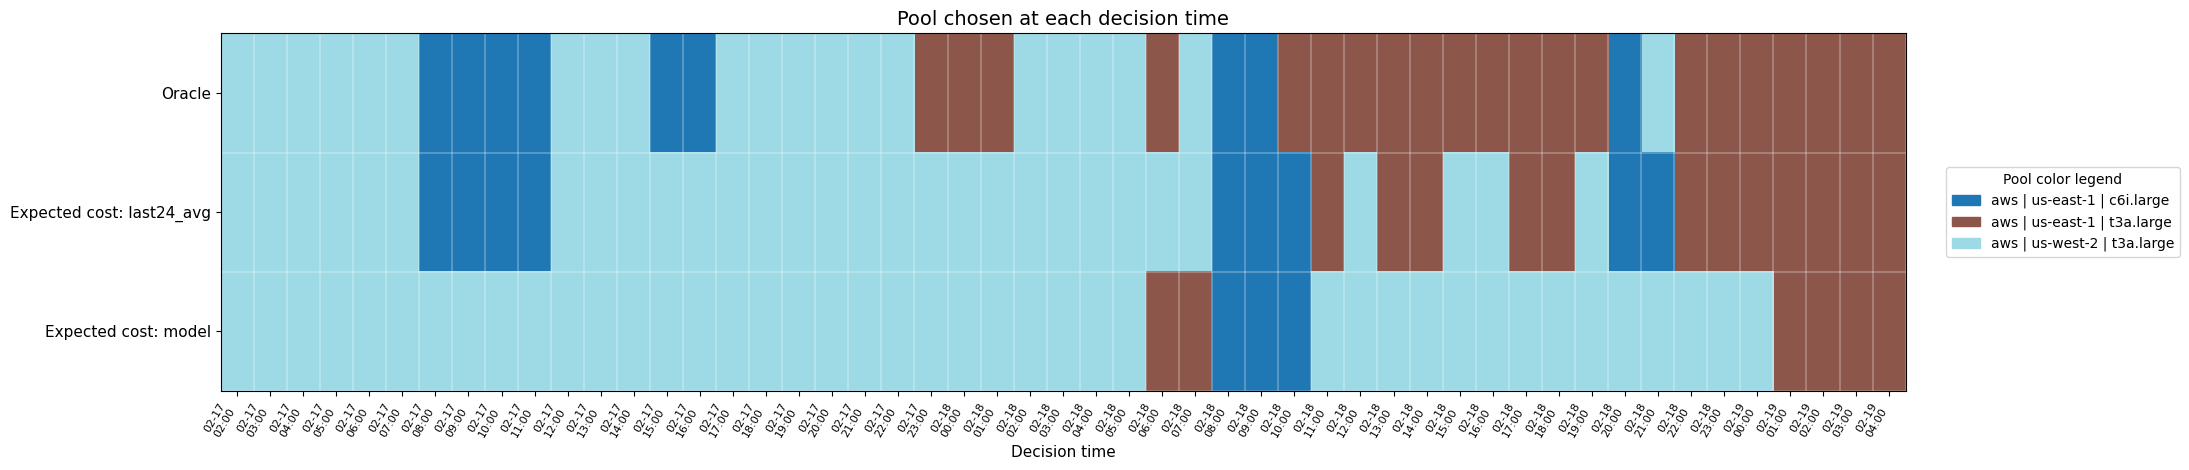

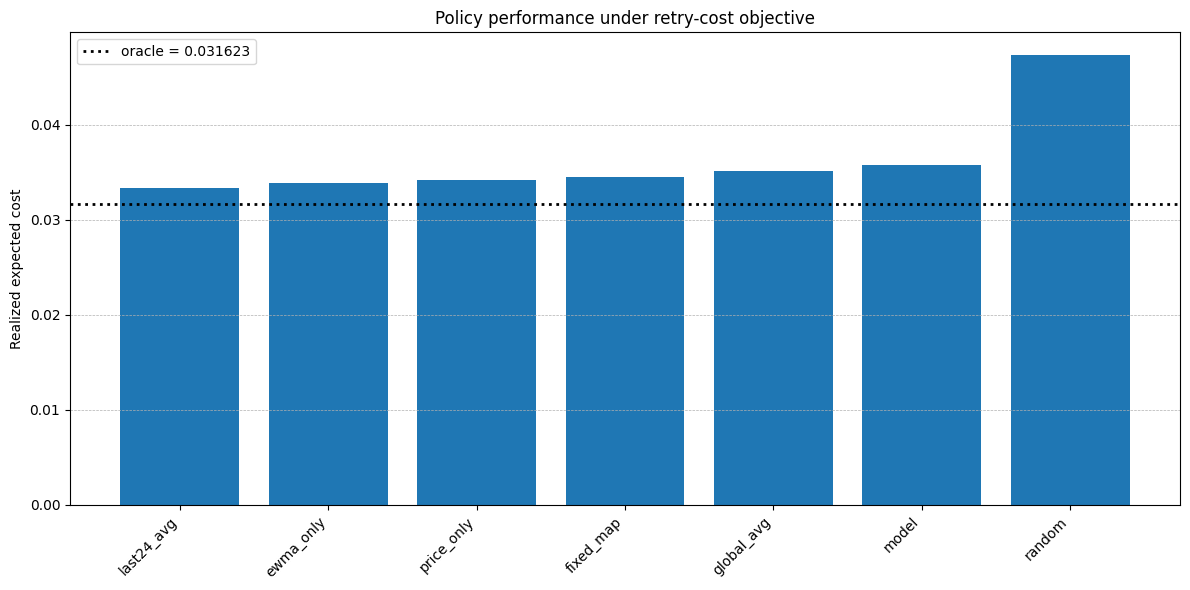

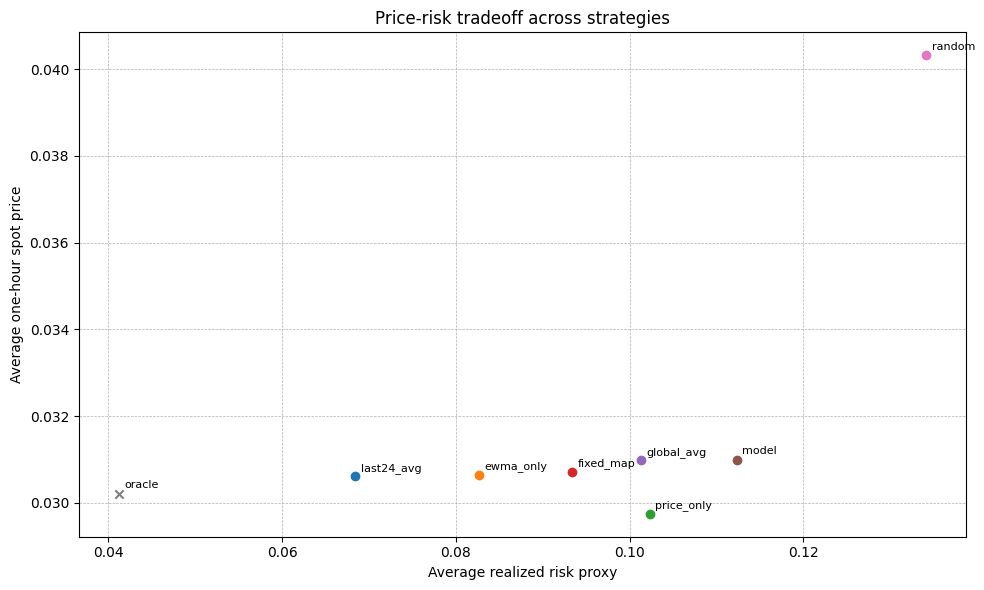

In [9]:
policy_outputs = run_retry_cost_policy_pipeline(block_hours=6, out_prefix="policy_eval")

In [10]:
ranking_outputs = run_three_pool_ranking_comparison(block_hours=6, existing_test_sorted=policy_outputs["test_sorted"])


Target pools being evaluated:
 - us-east-1 | c6i.large
 - us-east-1 | t3a.large
 - us-west-2 | t3a.large

Three-pool ranking comparison on TEST
Decision times evaluated: 46

--- Overall summary ---
Model exact ranking accuracy:  0.000000
Avg24 exact ranking accuracy:  0.413043
Model top1 hit rate:           0.000000
Avg24 top1 hit rate:           0.630435
Model mean pairwise accuracy:  0.398551
Avg24 mean pairwise accuracy:  0.739130
Model mean Spearman:           -0.195652
Avg24 mean Spearman:           0.510870
Model mean realized rank pick: 2.413043
Avg24 mean realized rank pick: 1.391304

--- Full per-decision-time table ---
            decision_time                                                            true_order                                                           model_order                                                           avg24_order  model_exact_match  avg24_exact_match  model_top1_hit  avg24_top1_hit  model_pairwise_acc  avg24_pairwise_acc  model_spearman 